In [1]:
import pandas as pd 
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# compare the total number of indels for the other 3 CRC cohorts 

In [3]:
# collect the cohorts 

tcga_msa = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/TCGA/results/output_tables/MSA_TCGA/pruned_attribution_MSA_TCGA_SBS_abs_mutations.csv',
                  index_col=0)

tcga_indel =  pd.read_table('/Users/kazachkova/Documents/tscc/restricted/TCGA_COAD_READ_new_data_download/mutect2_filtered_output/ID/mutect_TCGA_CRC.ID83.all',index_col=0).T


swedish_msa = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/SWEDISH/results/output_tables/MSA_SWEDISH/pruned_attribution_MSA_SWEDISH_SBS_abs_mutations.csv',
                  index_col=0)

swedish_indel = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/Swedish_data/data/output/ID/Swedish_data.ID83.all',index_col=0)


gel_msa = pd.read_csv('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/finalized_extractions_for_SBS288D_paper/MSA_runs/GEL/results/output_tables/MSA_GEL/pruned_attribution_MSA_GEL_SBS_abs_mutations.csv',
                  index_col=0)

gel_indel = pd.read_csv('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/GeL_analysis/GEL_activity_matrices/GEL_indel_activity.csv',index_col=0)


In [4]:
# for TCGA, C is 288B and D is 288D

In [5]:
tcga_indel.index = tcga_indel.index.str.split('_mutect2').str[0]

In [6]:
tcga_indel = tcga_indel.loc[tcga_msa.index]

tcga_indel['total_indels'] = tcga_indel.sum(axis=1)

tcga_indel['SBS_D'] = tcga_msa.loc[:,'SBS288D'] > 0

tcga_indel.loc[:,'SBS_D'] = tcga_indel.loc[:,'SBS_D'].astype(str).str.replace('True','SBS_D+').str.replace('False','SBS_D-')

In [7]:
swedish_indel.columns = swedish_indel.columns.str.split('genome_').str[-1]

#for swedish, B is B and E is D

swedish_indel = swedish_indel.loc[:,swedish_msa.index]
swedish_indel = swedish_indel.T
swedish_indel['total_indels'] = swedish_indel.sum(axis=1)

swedish_indel['SBS_D'] = swedish_msa.loc[:,'SBS288E'] > 0

swedish_indel.loc[:,'SBS_D'] = swedish_indel.loc[:,'SBS_D'].astype(str).str.replace('True','SBS_D+').str.replace('False','SBS_D-')



In [8]:
gel_indel = gel_indel.loc[gel_msa.index]
gel_indel=gel_indel.drop(['signature_extraction_group','Low count'],axis=1)

# for GEL, B is B and F is D 

gel_indel = gel_indel.loc[gel_msa.index]

gel_indel['total_indels'] = gel_indel.sum(axis=1)

gel_indel['SBS_D'] = gel_msa.loc[:,'SBS96F'] > 0

gel_indel.loc[:,'SBS_D'] = gel_indel.loc[:,'SBS_D'].astype(str).str.replace('True','SBS_D+').str.replace('False','SBS_D-')



In [9]:
from collections import Counter

/Users/kazachkova/miniconda3/lib/python3.9/site-packages/seaborn/categorical.py:1296: UserWarning: 27.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


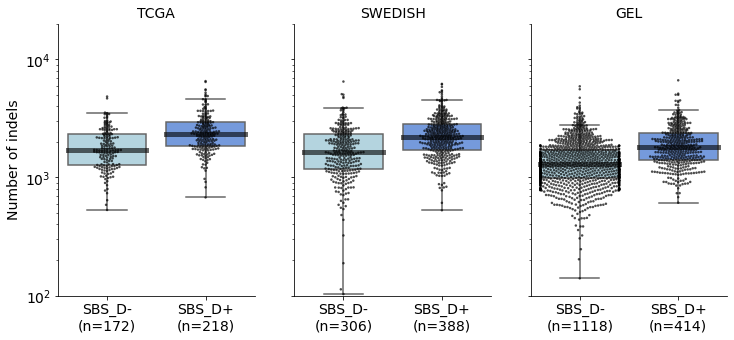

In [10]:
fig,ax = plt.subplots(1,3,figsize=(12,5),sharey=True)

# sns.boxplot(data=tcga_indel_,
#            x='SBS_D',y='total_indel_s',ax=ax[0])


tcga_indel_ = tcga_indel.copy()
swedish_indel_ = swedish_indel.copy()
gel_indel_= gel_indel.copy()

tcga_ns = pd.Series(Counter(tcga_indel_.loc[:,'SBS_D']))
tcga_indel_.loc[:,'SBS_D'] = tcga_indel_.loc[:,'SBS_D'] + '\n(n=' + tcga_ns.loc[tcga_indel_.loc[:,'SBS_D']].astype(str).values + ')'

sns.boxplot(data = tcga_indel_.sort_values('SBS_D',ascending=False),
            x='SBS_D',
            y='total_indels',
          # order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['lightblue','cornflowerblue'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[0],
           showfliers=False)


sns.swarmplot(data = tcga_indel_.sort_values('SBS_D',ascending=False),
            x='SBS_D',
            y='total_indels',
          #order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
          palette=['black','black'],ax=ax[0],alpha=.7,size=2.5)
           #color='black',alpha=.2)
    
    
    
    
swedish_ns = pd.Series(Counter(swedish_indel_.loc[:,'SBS_D']))
swedish_indel_.loc[:,'SBS_D'] = swedish_indel_.loc[:,'SBS_D'] + '\n(n=' + swedish_ns.loc[swedish_indel_.loc[:,'SBS_D']].astype(str).values + ')'
 
    
sns.boxplot(data = swedish_indel_.sort_values('SBS_D',ascending=False),
            x='SBS_D',
            y='total_indels',
          # order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['lightblue','cornflowerblue'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[1],
           showfliers=False)


sns.swarmplot(data = swedish_indel_.sort_values('SBS_D',ascending=False),
            x='SBS_D',
            y='total_indels',
          #order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
          palette=['black','black'],ax=ax[1],alpha=.7,size=2.5)
           #color='black',alpha=.2)
 



gel_ns = pd.Series(Counter(gel_indel_.loc[:,'SBS_D']))
gel_indel_.loc[:,'SBS_D'] = gel_indel_.loc[:,'SBS_D'] + '\n(n=' + gel_ns.loc[gel_indel_.loc[:,'SBS_D']].astype(str).values + ')'
 
sns.boxplot(data = gel_indel_.sort_values('SBS_D',ascending=False),
            x='SBS_D',
            y='total_indels',
          # order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
           palette=['lightblue','cornflowerblue'],
           medianprops=dict(color="black", alpha=0.6,
                                          linewidth=5),ax=ax[2],
           showfliers=False)


sns.swarmplot(data = gel_indel_.sort_values('SBS_D',ascending=False),
            x='SBS_D',
            y='total_indels',
          #order=['MSS\nSBS_D-\n(n=374)','MSS\nSBS_D+\n(n=428)'],
          palette=['black','black'],ax=ax[2],alpha=.7,size=2.5)
           #color='black',alpha=.2)
   


ax[0].set_yscale('log')
ax[0].set_ylim(100,20000)
ax[0].set_yticks([100,1000, 10000])


ax[0].set_xlabel('')
ax[1].set_xlabel('')
ax[2].set_xlabel('')

ax[0].set_ylabel('Number of indels')

ax[1].set_ylabel('')
ax[2].set_ylabel('')



ax[0].set_title('TCGA')
ax[1].set_title('SWEDISH')
ax[2].set_title('GEL')


for i in range(0,3):
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)

    for item in ([ ax[i].title,  ax[i].xaxis.label,  ax[i].yaxis.label] +
                  ax[i].get_xticklabels() +  ax[i].get_yticklabels()):
        item.set_fontsize(14)
        
        
# plt.savefig('plots_for_paper/indels_other_cohorts.png',dpi=300)

In [11]:
# have the plots, now want to do the significance testing 

In [12]:
# TCGA 

# now we need to look at the TCGA metadata to see if these samples have all the info we need 

# maybe we wanna do this per tumor location 
# I guess that would be in the clinical sheet

clinical = pd.read_table('/Users/kazachkova/Downloads/old_laptop_downloads/clinical.project-tcga-coad.2024-05-23/clinical.tsv',index_col=1)

clinical2 = pd.read_table('/Users/kazachkova/Downloads/old_laptop_downloads/clinical.project-tcga-read.2024-04-29/clinical.tsv',index_col=1)



all_clinical = pd.concat([clinical,clinical2])

# The right colon consists of the cecum, ascending colon, hepatic flexure and the right half of the transverse colon. The left colon consists of the left half of the transverse colon, splenic flexure, descending colon, and sigmoid

# C20 - Rectum	Rectum
# C18.7 - Sigmoid	Distal colon
# C18.3 - Hepatic flexure	Proximal colon
# C18.0 - Cecum	Proximal colon
# C18.2 - Right (ascending) colon	Proximal colon
# C18.6 - Left (descending) colon	Distal colon
# C19.9 - Rectosigmoid junction	Rectum
# C18.5 - Splenic flexure	Distal colon
# C18.4 - Transverse colon	Proximal colon
# C18.0 - Cecum; C18.2 - Right (ascending) colon	Proximal colon
# C18.6 - Left (descending) colon; C18.7 - Sigmoid	Distal colon
# C18.9 - Colon not otherwise specified	Other
# Other	Other
# C18.2 - Right (ascending) colon; C18.4 - Trans...	Proximal colon

for_map = pd.Series('Other',index = set(all_clinical.loc[:,'site_of_resection_or_biopsy']),dtype=str)
for_map.loc['Hepatic flexure of colon'] = 'Proximal'
for_map.loc['Transverse colon'] = 'Proximal'
for_map.loc['Cecum'] = 'Proximal'
for_map.loc['Splenic flexure of colon'] = 'Distal'
for_map.loc['Sigmoid colon'] = 'Distal'
for_map.loc['Rectum, NOS'] = 'Rectum'
for_map.loc['Ascending colon'] = 'Proximal'
for_map.loc['Rectosigmoid junction'] = 'Rectum'
for_map.loc['Descending colon'] = 'Distal'
for_map

all_clinical=all_clinical[~all_clinical.index.duplicated()]

# temp['subsite'] = for_map.loc[all_clinical.loc[temp.index,'site_of_resection_or_biopsy']].values


all_clinical['subsite'] = for_map.loc[all_clinical.loc[all_clinical.index,'site_of_resection_or_biopsy']].values


# tcga_keep= all_clinical.loc[tcga_keep][all_clinical.loc[good_tcga_muts,'age_at_index']!='\'--'].loc[:,'age_at_index'].index
# tcga_keep= all_clinical.loc[tcga_keep][all_clinical.loc[good_tcga_muts,'subsite']!='Other'].index



# and sex is fine here 
# tcga_keep= all_clinical.loc[good_tcga_muts][all_clinical.loc[good_tcga_muts,'treatment_or_therapy']!='yes'].index



In [13]:
tcga_metadata = all_clinical.loc[:,['gender','age_at_index','subsite']]

tcga_indel['sex'] = tcga_metadata.loc[:,'gender']
tcga_indel['age'] = tcga_metadata.loc[:,'age_at_index']
tcga_indel['subsite'] = tcga_metadata.loc[:,'subsite']

In [14]:
purity = pd.Series(index = tcga_indel_.index)
# now do it for all our samples of interest
import os

for sample in purity.index:
    
    if not os.path.exists('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/battenberg_TCGA_data/results/' + sample + '/' + sample + '_tumor_rho_and_psi.txt'):
                          continue
  
    
    rho_psi = pd.read_table('/Users/kazachkova/Documents/tscc/restricted/mutographs/CRC/battenberg_TCGA_data/results/' + sample + '/' + sample + '_tumor_rho_and_psi.txt')

    purity.loc[sample] = rho_psi[rho_psi.loc[:,'is.best'] == True].loc[:,'rho'].values[0]
    
    


tcga_indel['purity'] = purity

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89816/878608942.py:1: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  purity = pd.Series(index = tcga_indel_.index)


In [15]:
import statsmodels.api as sm

import statsmodels.formula.api as smf

In [16]:
tcga_indel_ = tcga_indel.copy()

tcga_indel_['SBS_D_bool'] = (tcga_indel_.loc[:,'SBS_D'].str.contains('\+')).astype(int)
tcga_indel_.loc[:,'age'] = tcga_indel_.loc[:,'age'].replace('\'--',float('nan')).astype(float)

import statsmodels.api as sm

import statsmodels.formula.api as smf

model = smf.glm(formula = 'SBS_D_bool' + " ~ total_indels + age + subsite + sex + purity", 
                data =tcga_indel_, family = sm.families.Binomial())
                #family = sm.families.Binomial())

    
result = model.fit()
result_table = result.summary2().tables[1]
result_table=result_table.drop('Intercept')
result_table

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89816/867931327.py:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  tcga_indel_.loc[:,'age'] = tcga_indel_.loc[:,'age'].replace('\'--',float('nan')).astype(float)


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
subsite[T.Other],-0.462693,0.350994,-1.318236,1.874247e-01,-1.150628,0.225243
subsite[T.Proximal],-0.721940,0.322936,-2.235552,2.538113e-02,-1.354883,-0.088997
subsite[T.Rectum],0.296788,0.306442,0.968495,3.327974e-01,-0.303828,0.897403
sex[T.female],-0.502208,0.270989,-1.853245,6.384730e-02,-1.033336,0.028920
sex[T.male],-0.107529,0.284568,-0.377869,7.055283e-01,-0.665272,0.450214
total_indels,0.001244,0.000178,6.998974,2.578432e-12,0.000895,0.001592
age,-0.003763,0.009266,-0.406068,6.846929e-01,-0.021923,0.014398
purity,-1.739013,0.707323,-2.458584,1.394860e-02,-3.125340,-0.352686


In [17]:
# lets do swedish 

swed_metadata = pd.read_csv('/Users/kazachkova/Documents/alexandrov_lab/mutographs/CRC_clonal_analysis/V3_Data/data_from_other_papers/Swedish_data/supp_tables/Supplementary_Table_01.csv',index_col=1,
                           skiprows=[0,1])

swedish_meta = swed_metadata.loc[:,['Sex','Age at diagnosis','Tumour Site']]
swedish_meta.columns = swedish_meta.columns.str.replace(' ','_')

swedish_indel['age'] = swedish_meta.loc[:,'Age_at_diagnosis']
swedish_indel['sex'] = swedish_meta.loc[:,'Sex']
swedish_indel['subsite'] = swedish_meta.loc[:,'Tumour_Site']

swedish_indel['purity'] = swed_metadata.loc[:,'Tumour Cell Content Pathology']/100



In [19]:
swedish_indel_ = swedish_indel.copy()

swedish_indel_['SBS_D_bool'] = (swedish_indel_.loc[:,'SBS_D'].str.contains('\+')).astype(int)
swedish_indel_.loc[:,'age'] = swedish_indel_.loc[:,'age'].replace('\'--',float('nan')).astype(float)

import statsmodels.api as sm

import statsmodels.formula.api as smf

model = smf.glm(formula = 'SBS_D_bool' + " ~ total_indels + age + subsite + sex + purity", 
                data =swedish_indel_, family = sm.families.Binomial())
                #family = sm.families.Binomial())

    
result = model.fit()
result_table = result.summary2().tables[1]
result_table=result_table.drop('Intercept')
result_table

/var/folders/hm/tm8gk7s95dz827sk5fljrj2r0000gn/T/ipykernel_89816/3553897327.py:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  swedish_indel_.loc[:,'age'] = swedish_indel_.loc[:,'age'].replace('\'--',float('nan')).astype(float)


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
subsite[T.Rectum],-0.127398,0.207871,-0.612871,5.399619e-01,-0.534816,0.280021
subsite[T.Right Colon],-0.304811,0.196680,-1.549784,1.211934e-01,-0.690297,0.080674
sex[T.Male],-0.247758,0.162705,-1.522737,1.278246e-01,-0.566654,0.071139
total_indels,0.000718,0.000106,6.747903,1.499974e-11,0.000509,0.000926
age,0.014413,0.007364,1.957199,5.032406e-02,-0.000020,0.028846
purity,0.138454,0.521107,0.265692,7.904766e-01,-0.882897,1.159805


In [21]:
# and then for the GEL data, we have to just do a basic test
# since no metadata is available

from scipy import stats
stats.mannwhitneyu(gel_indel[gel_indel.loc[:,'SBS_D'].str.contains('\-')].loc[:,'total_indels'],
                  gel_indel[gel_indel.loc[:,'SBS_D'].str.contains('\+')].loc[:,'total_indels'])

MannwhitneyuResult(statistic=128001.5, pvalue=3.081605732954242e-41)